<a href="https://colab.research.google.com/github/toshikis/AISeminar/blob/%E5%BE%A9%E7%BF%92%E7%94%A8%E6%95%99%E6%9D%90/%E6%A9%9F%E6%A2%B0%E5%AD%A6%E7%BF%92%E5%BF%9C%E7%94%A8%E2%91%A2%E6%9D%B1%E4%BA%AC23%E5%8C%BA%E8%B3%83%E8%B2%B8%E7%89%A9%E4%BB%B6%E3%81%AE%E5%AE%B6%E8%B3%83%E4%BA%88%E6%B8%AC_%E8%AC%9B%E5%B8%AB%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=#0e89b2>0. 使用するライブラリのインポート</font>

In [ ]:
#Colabには入っていないretryライブラリをインストール
!pip install retry

In [ ]:
#Webスクレイピングで使用するライブラリをインポート
import requests
from bs4 import BeautifulSoup
from retry import retry
import urllib
import time
import numpy as np
import pandas as pd

#機械学習モデル
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb
import xgboost as xgb


#機械学習ライブラリ　sklearn ユーティリティ
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

#データフレームが全列表示されるように設定
pd.set_option('display.max_columns', None)

# <font color=#0e89b2>1. 家賃予測</font>

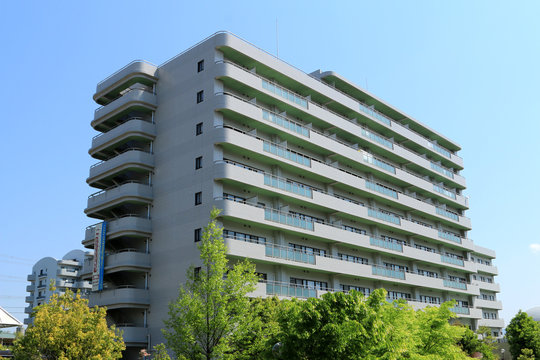

この単元では、東京23区の物件情報から家賃を予測するモデルを作成していきます。<br>
物件情報から家賃を予測するので、回帰タスクになります。<br>
<br>
使用するデータはSUUMOのサイトからスクレイピングによって取得します。<br>
スクレイピングとは、Webサイトから大量の情報を自動的に抽出することです。<br>
<br>
この単元ではスクレイピングの手法自体には詳しくは触れませんが、<br>
コードを載せているので、興味がある方は参考にしてみてください。<br>


#<font color=#0e89b2>2. ウォーミングアップ</font>

今回の演習では、文字列の処理やデータ型の変換を行う場面が多く出てきます。<br>
一度ウォーミングアップをしておきましょう。<br>
以下の関数を使用します。<br>
<br>

---


* 置換: str.replace()
 * 使用例）df['カラム名'].str.replace('置換前', '置換後')
* 削除: str.strip()
 * 使用例）df['カラム名'].str.strip('削除する文字列')
* 分割: str.split()
 * 使用例）df['カラム名'].str.split('分割の区切りとなる文字列')
 * 例えば、「aaa@gmail.com」を「@」で分割すると、「aaa」と「gmail.com」になります
---

また、データ型の変換はastype()メソッドを使います。<br>
それではデータを準備していきます。

In [ ]:
practice = pd.DataFrame({
              "学生ID":[1,2,3,4,5],
              "住所":["渋谷区","荒川区","豊島区","品川区","目黒区"],
              "経験年数":[0,"未経験","3",5,2],
              "得点":["89点","76点","32点","54点","17点"]})

In [ ]:
practice

,学生ID,住所,経験年数,得点
0,1,渋谷区,0,89点
1,2,荒川区,未経験,76点
2,3,豊島区,3,32点
3,4,品川区,5,54点
4,5,目黒区,2,17点


(1) 「住所」のカラムから「区」の文字を除いてください。

(2) 「得点」のカラムから「点」の文字を除いて、全て数値型(int)に直してください。

(3) 「経験年数」を全て数値型(int)に直してください。

解答

(1)

In [ ]:
practice["住所"] =practice["住所"].str.strip("区")
practice

,学生ID,住所,経験年数,得点
0,1,渋谷,0,89点
1,2,荒川,未経験,76点
2,3,豊島,3,32点
3,4,品川,5,54点
4,5,目黒,2,17点


(2)

In [ ]:
practice["得点"] = practice["得点"].str.strip("点")
practice["得点"] = practice["得点"].astype(int)
practice

,学生ID,住所,経験年数,得点
0,1,渋谷,0,89
1,2,荒川,未経験,76
2,3,豊島,3,32
3,4,品川,5,54
4,5,目黒,2,17


(3)

In [ ]:
practice["経験年数"] = practice["経験年数"].astype(str)
practice["経験年数"] = practice["経験年数"].str.replace("未経験","0")
practice["経験年数"] = practice["経験年数"].astype(int)
practice

,学生ID,住所,経験年数,得点
0,1,渋谷,0,89
1,2,荒川,0,76
2,3,豊島,3,32
3,4,品川,5,54
4,5,目黒,2,17


# <font color=#0e89b2>3. データの準備</font>

## <font color=#0e89b2>3.1 データのダウンロード</font>

今回は、SUUMOのサイトからスクレイピングによって物件情報のデータを取得しています。<br>
スクレイピング実行結果の取得済みデータをすでに準備してあるので、こちらをダウンロードしましょう。<br>
https://drive.google.com/file/d/1-CED367yBH-7hRPbzQ86pNhKeMtrgn5F/view?usp=drive_link

## <font color=#0e89b2>3.2 参考）スクレイピング</font>

以下は、上のデータを取得する際に使用した、Webスクレイピングのコードです。<br>
HPの東京23区の検索結果から20ページ(max_page = 20)だけスクレイピングしています。<br>
実行すると２分ほど時間がかかります。<br>
<br>
興味のある方はコードを読んでみてください。<br>
なお、スクレイピングはデータ取得先のホームページに連続自動的にアクセスをかける行為であり、<br>
サーバーに負荷をかけてしまう可能性があるため、<br>
下のコードを無闇に実行するのは控えておきましょう。<br>
<br>
また、スクレイピングを行う際には、当ホームページの利用規約を読んで、<br>
スクレイピング行為が禁止されていないか必ず確認しておきましょう。<br>
SUUMOではスクレイピングを禁止する条項はありませんが、あまりに負荷をかけすぎると、<br>
「(6) 本サイトの運営を妨げる行為」に該当するおそれがあるため、注意しましょう。

In [ ]:
# #Webスクレイピングのコード
# # 複数ページの情報をまとめて取得
# data_samples = []

# # スクレイピングするページ数
# max_page = 100
# # SUUMOを東京都23区のみ指定して検索して出力した画面のurl(ページ数フォーマットが必要)※HPが更新されるとエラーになる可能性があります。
# url = 'https://suumo.jp/jj/chintai/ichiran/FR301FC001/?ar=030&bs=040&ta=13&sc=13101&sc=13102&sc=13103&sc=13104&sc=13105&sc=13113&sc=13106&sc=13107&sc=13108&sc=13118&sc=13121&sc=13122&sc=13123&sc=13109&sc=13110&sc=13111&sc=13112&sc=13114&sc=13115&sc=13120&sc=13116&sc=13117&sc=13119&cb=0.0&ct=9999999&et=9999999&cn=9999999&mb=0&mt=9999999&shkr1=03&shkr2=03&shkr3=03&shkr4=03&fw2=&srch_navi=1&page={}'
# # リクエストがうまく行かないパターンを回避するためのやり直し
# @retry(tries=3, delay=10, backoff=2)
# def load_page(url):
#     html = requests.get(url)
#     soup = BeautifulSoup(html.content, 'html.parser')
#     return soup

# # 処理時間を測りたい
# start = time.time()
# times = []

# # ページごとの処理
# for page in range(1,max_page+1):
#     before = time.time()
#     # ページ情報
#     soup = load_page(url.format(page))
#     # 物件情報リストを指定
#     mother = soup.find_all(class_='cassetteitem')

#     # 物件ごとの処理
#     for child in mother:

#         # 建物情報
#         data_home = []
#         # カテゴリ
#         data_home.append(child.find(class_='ui-pct ui-pct--util1').text)
#         # 建物名
#         data_home.append(child.find(class_='cassetteitem_content-title').text)
#         # 住所
#         data_home.append(child.find(class_='cassetteitem_detail-col1').text)
#         # 最寄り駅のアクセス
#         #children = child.find(class_='cassetteitem_detail-col2')
#         #for id,grandchild in enumerate(children.find_all(class_='cassetteitem_detail-text')):
#         #    data_home.append(grandchild.text)
#         # 築年数と階数
#         children = child.find(class_='cassetteitem_detail-col3')
#         for grandchild in children.find_all('div'):
#             data_home.append(grandchild.text)

#         # 部屋情報
#         rooms = child.find(class_='cassetteitem_other')
#         for room in rooms.find_all(class_='js-cassette_link'):
#             data_room = []

#             # 部屋情報が入っている表を探索
#             for id_, grandchild in enumerate(room.find_all('td')):
#                 # 階
#                 if id_ == 2:
#                     data_room.append(grandchild.text.strip())
#                 # 家賃と管理費
#                 elif id_ == 3:
#                     data_room.append(grandchild.find(class_='cassetteitem_other-emphasis ui-text--bold').text)
#                     data_room.append(grandchild.find(class_='cassetteitem_price cassetteitem_price--administration').text)
#                 # 敷金と礼金
#                 elif id_ == 4:
#                     data_room.append(grandchild.find(class_='cassetteitem_price cassetteitem_price--deposit').text)
#                     data_room.append(grandchild.find(class_='cassetteitem_price cassetteitem_price--gratuity').text)
#                 # 間取りと面積
#                 elif id_ == 5:
#                     data_room.append(grandchild.find(class_='cassetteitem_madori').text)
#                     data_room.append(grandchild.find(class_='cassetteitem_menseki').text)
#                 # url
#                 elif id_ == 8:
#                     get_url = grandchild.find(class_='js-cassette_link_href cassetteitem_other-linktext').get('href')
#                     abs_url = urllib.parse.urljoin(url,get_url)
#                     data_room.append(abs_url)
#             # 物件情報と部屋情報をくっつける
#             data_sample = data_home + data_room
#             data_samples.append(data_sample)

#     # 1アクセスごとに1秒休む
#     time.sleep(1)

#     # 進捗確認
#     # このページの作業時間を表示
#     after = time.time()
#     running_time = after - before
#     times.append(running_time)
#     print(f'{page}ページ目：{running_time}秒')
#     # 取得した件数
#     print(f'総取得件数：{len(data_samples)}')
#     # 作業進捗
#     complete_ratio = round(page/max_page*100,3)
#     print(f'完了：{complete_ratio}%')
#     # 作業の残り時間目安を表示
#     running_mean = np.mean(times)
#     running_required_time = running_mean * (max_page - page)
#     hour = int(running_required_time/3600)
#     minute = int((running_required_time%3600)/60)
#     second = int(running_required_time%60)
#     print(f'残り時間：{hour}時間{minute}分{second}秒\n')

# # 音を出す
# def sound():
#     !rundll32 user32.dll,MessageBeep

# # 処理時間を測りたい
# finish = time.time()
# running_all = finish - start
# print('総経過時間：',running_all)
# sound()

In [ ]:
#Webスクレイピング時の出力結果はlist型なのでpandasのDataFrame型にする
#df_data = pd.DataFrame(data_samples)

NameError: name 'data_samples' is not defined

In [ ]:
#一度、csvとして保存しておきます。
#df_data.to_csv("rent_data.csv")

# <font color=#0e89b2>4. 演習</font>

##<font color=#0e89b2>4.1 演習問題1：モデルの構築・評価</font>

それでは本題に入っていきます。<br>
上でダウンロードしたデータを使用して、物件情報から家賃を取得するモデルを構築してみてください。<br>
自身で学習データとテストデータに分割して、スコアを算出しましょう。<br>
* 説明変数：築年数、建物階数、所在階数、面積、住所、建物種別、間取り
* 目的変数：家賃

##<font color=#0e89b2>4.2 演習問題2：自宅の家賃を予測</font>

出来上がったモデルを使って、今の自分の家の家賃を正しく予測できるか試してみてください。<br>
（東京23区以外に在住の方は家賃相場が異なりますが、参考程度にやってみましょう）

# <font color=#0e89b2>5. 解答例</font>

ここからは、現役のAIエンジニア/データサイエンティストの実際の解答になります。<br>
一定時間内で解答しているため、もちろんさらなる精度向上余地は考えられますが、<br>
是非考え方や手法を取り入れてみてください。<br>
<br>
またこの単元の解答作成担当者は、タイタニックの時とはまた別のAIエンジニアです。<br>
アプローチの共通点や相違点にも注意しながら見てみましょう。

## <font color=#0e89b2>5.1 データの確認</font>

### <font color=#0e89b2>(1) データ読み込み</font>

先ほどのリンクからダウンロードしたデータ（rent_data.csv)をGoogle Colabにアップロードし、<br>
いつものように読み込んでいきましょう。

In [ ]:
#pandas(pd)のread_csvメソッドでデータを読み込み
df = pd.read_csv("sample_data/rent_data.csv")

#変換前の生データを変数df_initとして保存しておきます。
df_init = df.copy()

### <font color=#0e89b2>(2) データ確認①：データ表示</font>

項目(カラム)名を見てみると「Unnamed:0」や数字が並んでいます。<br>
Webスクレイピング時の出力はlist型で、その後、pandasのDataFrame型に変換したので<br>
項目(カラム)名はUnnamed(名前が付いていない)のままです。<br>
<br>
中身の物件情報のデータは正しく取得できていそうです。

In [ ]:
df.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0,賃貸マンション,秀和青山神宮前レジデンス,東京都渋谷区神宮前２,築26年,15階建,4階,32万円,-,64万円,32万円,2LDK,73.62m2,https://suumo.jp/chintai/jnc_000087251920/?bc=...
1,1,賃貸マンション,トキアス,東京都荒川区南千住８,築20年,20階建,5階,22万円,-,22万円,22万円,3SLDK,80.73m2,https://suumo.jp/chintai/jnc_000087205285/?bc=...
2,2,賃貸マンション,トキアス,東京都荒川区南千住８,築20年,20階建,8階,22万円,20000円,22万円,22万円,4LDK,90.48m2,https://suumo.jp/chintai/jnc_000087990974/?bc=...
3,3,賃貸マンション,アーバンキャッスル田端,東京都荒川区西尾久４,築15年,13階建,2階,12万円,10000円,12万円,12万円,1LDK,41.09m2,https://suumo.jp/chintai/jnc_000087939552/?bc=...
4,4,賃貸マンション,アーバンキャッスル田端,東京都荒川区西尾久４,築15年,13階建,5階,13万円,15000円,13万円,26万円,1LDK,43.18m2,https://suumo.jp/chintai/jnc_000070420868/?bc=...


### <font color=#0e89b2>(3) データ確認②：データサイズ確認</font>

データのサイズを表示してみます。<br>
pandas(pd)のshapeメソッドで、dfという変数に代入された表形式のデータのサイズを求めることができます。<br>
データサイズはHPの情報更新により、Webスクレイピングの度に異なることがあります。<br>
14は１データ当たりの項目(カラム)数です。

In [ ]:
df.shape

(10985, 14)

### <font color=#0e89b2>(4) データ確認③：カラム名をつける</font>

今のデータには各項目(各カラム)の名前がないので、分かりやすくするために名前を付けましょう。<br>
<br>
pandas(pd)のcolumnsメソッドで、dfという変数に代入された表形式のデータの各項目(各カラム)の名前を付けます。



In [ ]:
df.columns =['id','種別','建物名','住所','築年数','建物階数','階数','家賃','管理費','敷金','礼金','間取り','面積','URL']

無事名付けが完了したか確認しておきます。

In [ ]:
df.head()

,id,種別,建物名,住所,築年数,建物階数,階数,家賃,管理費,敷金,礼金,間取り,面積,URL
0,0,賃貸マンション,秀和青山神宮前レジデンス,東京都渋谷区神宮前２,築26年,15階建,4階,32万円,-,64万円,32万円,2LDK,73.62m2,https://suumo.jp/chintai/jnc_000087251920/?bc=...
1,1,賃貸マンション,トキアス,東京都荒川区南千住８,築20年,20階建,5階,22万円,-,22万円,22万円,3SLDK,80.73m2,https://suumo.jp/chintai/jnc_000087205285/?bc=...
2,2,賃貸マンション,トキアス,東京都荒川区南千住８,築20年,20階建,8階,22万円,20000円,22万円,22万円,4LDK,90.48m2,https://suumo.jp/chintai/jnc_000087990974/?bc=...
3,3,賃貸マンション,アーバンキャッスル田端,東京都荒川区西尾久４,築15年,13階建,2階,12万円,10000円,12万円,12万円,1LDK,41.09m2,https://suumo.jp/chintai/jnc_000087939552/?bc=...
4,4,賃貸マンション,アーバンキャッスル田端,東京都荒川区西尾久４,築15年,13階建,5階,13万円,15000円,13万円,26万円,1LDK,43.18m2,https://suumo.jp/chintai/jnc_000070420868/?bc=...


### <font color=#0e89b2>(5) データ確認④：欠損値とデータタイプの確認</font>

各項目(各カラム)に欠損値がないかと、各項目(各カラム)のデータタイブを調べてみます。<br>
欠損値はプログラミングではnull値と呼ばれることがあります。<br>
<br>
pandas(pd)のinfoメソッドを使うと、以下の項目を一発で調べることができます。<br>
*   欠損値(null値)ではないデータの数(Non-Null Count)
*   データタイブ(Dtype)




In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10985 entries, 0 to 10984
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      10985 non-null  int64 
 1   種別      10985 non-null  object
 2   建物名     10985 non-null  object
 3   住所      10985 non-null  object
 4   築年数     10985 non-null  object
 5   建物階数    10985 non-null  object
 6   階数      10985 non-null  object
 7   家賃      10985 non-null  object
 8   管理費     10985 non-null  object
 9   敷金      10985 non-null  object
 10  礼金      10985 non-null  object
 11  間取り     10985 non-null  object
 12  面積      10985 non-null  object
 13  URL     10985 non-null  object
dtypes: int64(1), object(13)
memory usage: 1.2+ MB


表示結果をみると、すべてのカラムについて"non-nul"lと表示さているので、<br>
欠損値(null値)はないことがわかります。<br>
またDtypeはint64型(64bit整数の数値データ)とobject型(カテゴリデータ)の２種類が<br>
あり、各項目(各カラム)が数値データか、カテゴリデータであることを示しています。

今回のデータは、欠損値(null値)がありませんでしたが、<br>
欠損値(null値)がある場合は、データを入力するモデルによってはゼロで埋める等の処理が必要になる場合があります。


また、他に欠損値(null値)を確認する方法として<br>
pandas(pd)のisnullメソッドにsumメソッドを連結させて求めることができます。

In [ ]:
df.isnull().sum()

id      0
種別      0
建物名     0
住所      0
築年数     0
建物階数    0
階数      0
家賃      0
管理費     0
敷金      0
礼金      0
間取り     0
面積      0
URL     0
dtype: int64

## <font color=#0e89b2>5.2 データ前処理</font>

### <font color=#0e89b2>(1) データ前処理①：特徴量の選択</font>

In [ ]:
df.columns

Index(['id', '種別', '建物名', '住所', '築年数', '建物階数', '階数', '家賃', '管理費', '敷金', '礼金',
       '間取り', '面積', 'URL'],
      dtype='object')

この中から、今回用いる特徴量だけに絞り込んでおきます。<br>
pandas(pd)のdropメソッドを使って、削除します。









In [ ]:
df = df.drop(['id','建物名','URL','管理費','敷金','礼金'],axis=1)
df.head()

,種別,住所,築年数,建物階数,階数,家賃,間取り,面積
0,賃貸マンション,東京都渋谷区神宮前２,築26年,15階建,4階,32万円,2LDK,73.62m2
1,賃貸マンション,東京都荒川区南千住８,築20年,20階建,5階,22万円,3SLDK,80.73m2
2,賃貸マンション,東京都荒川区南千住８,築20年,20階建,8階,22万円,4LDK,90.48m2
3,賃貸マンション,東京都荒川区西尾久４,築15年,13階建,2階,12万円,1LDK,41.09m2
4,賃貸マンション,東京都荒川区西尾久４,築15年,13階建,5階,13万円,1LDK,43.18m2


### <font color=#0e89b2>(2) データ前処理②：カテゴリデータから数値データへ変換</font>

データを見てみると、本来は数値データとして扱いたいのに、<br>
数字と単位等が合わさってカテゴリデータになってしまっているものが多数あります。<br>
* 例）家賃：12.6万円
* 例）築年数：築8年

このようなデータから単位等を取り除き、数値データに変換していきます。

#### <font color=#0e89b2>a. 築年数</font>

In [ ]:
#築年数のデータの種類を表示。uniqueメソッドを使用
df['築年数'].unique()

array(['築26年', '築20年', '築15年', '築11年', '新築', '築14年', '築4年', '築12年', '築6年',
       '築16年', '築8年', '築2年', '築9年', '築31年', '築5年', '築33年', '築27年', '築7年',
       '築19年', '築17年', '築22年', '築3年', '築10年', '築13年', '築1年', '築35年',
       '築0年', '築47年', '築38年', '築29年', '築43年', '築28年', '築18年', '築77年',
       '築25年', '築21年', '築32年', '築23年', '築36年', '築62年', '築30年', '築24年',
       '築34年', '築39年', '築37年', '築55年', '築48年', '築54年', '築59年', '築44年',
       '築53年', '築40年', '築46年', '築45年', '築42年', '築51年', '築50年', '築65年',
       '築49年', '築41年', '築57年', '築52年', '築68年', '築63年', '築69年'],
      dtype=object)

In [ ]:
#築年数の内、新築は0に置換　str.replaceメソッドを使用
df['築年数'] = df['築年数'].str.replace('新築','0')

#築年数の内、築と年の文字を削除　str.stripメソッドを使用
df['築年数'] = df['築年数'].str.strip('築年')

#データ型をint(整数)に変換　astypeメソッドを使用
df['築年数'] = df['築年数'].astype(int)

In [ ]:
#変換後の築年数のデータの種類を表示
df['築年数'].unique()

array([26, 20, 15, 11,  0, 14,  4, 12,  6, 16,  8,  2,  9, 31,  5, 33, 27,
        7, 19, 17, 22,  3, 10, 13,  1, 35, 47, 38, 29, 43, 28, 18, 77, 25,
       21, 32, 23, 36, 62, 30, 24, 34, 39, 37, 55, 48, 54, 59, 44, 53, 40,
       46, 45, 42, 51, 50, 65, 49, 41, 57, 52, 68, 63, 69])

In [ ]:
import matplotlib.pyplot as plt


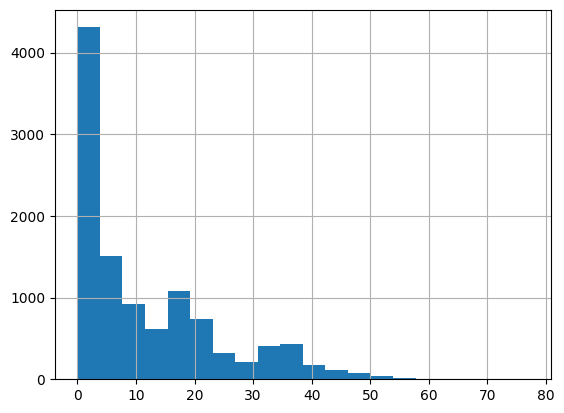

In [ ]:
#築年数の分布を表示
plt.hist(df["築年数"], bins=20)
plt.grid(True)

かなり築浅に分布が寄っているのが気になりますが、このまま進めていきましょう。<br>
（Suumoで上位表示される物件が、築浅物件メインなのかもしれません）

#### <font color=#0e89b2>b. 建物階数</font>

In [ ]:
#建物階数のデータの種類を表示。
df['建物階数'].unique()

array(['15階建', '20階建', '13階建', '3階建', '12階建', '11階建', '2階建', '5階建', '7階建',
       '8階建', '6階建', '10階建', '9階建', '4階建', '地下1地上10階建', '14階建',
       '地下1地上12階建', '地下1地上5階建', '53階建', '18階建', '地下1地上3階建', '地下2地上40階建',
       '地下1地上14階建', '16階建', '地下1地上18階建', '地下1地上6階建', '地下1地上19階建',
       '地下1地上4階建', '地下1地上9階建', '22階建', '地下1地上8階建', '28階建', '地下1地上28階建',
       '地下1地上15階建', '地下2地上13階建', '地下1地上7階建', '地下1地上13階建', '地下1地上2階建',
       '地下3地上30階建', '地下2地上14階建', '地下1地上48階建', '地下2地上9階建', '30階建',
       '地下1地上11階建', '地下1地上24階建', '地下1地上31階建', '地下2地上4階建', '地下1地上29階建',
       '24階建', '地下3地上38階建', '56階建', '地下2地上60階建', '地下1地上21階建', '21階建',
       '地下2地上11階建', '地下2地上21階建', '地下4地上44階建', '地下1地上22階建', '地下4地上36階建',
       '地下2地上10階建', '地下2地上44階建', '地下1地上16階建'], dtype=object)

In [ ]:
#地下は簡略化のため、削除する。str.replaceメソッドで無しに置換
df['建物階数'] = df['建物階数'].str.replace('地下1地上','')
df['建物階数'] = df['建物階数'].str.replace('地下2地上','')
df['建物階数'] = df['建物階数'].str.replace('地下3地上','')
df['建物階数'] = df['建物階数'].str.replace('地下4地上','')
df['建物階数'] = df['建物階数'].str.replace('地下5地上','')

#階建の文字を削除
df['建物階数'] = df['建物階数'].str.strip('階建')

#データ型をint(整数)に変換
df['建物階数'] = df['建物階数'].astype(int)

In [ ]:
#変換後の建物階数のデータの種類を表示。
df['建物階数'].unique()

array([15, 20, 13,  3, 12, 11,  2,  5,  7,  8,  6, 10,  9,  4, 14, 53, 18,
       40, 16, 19, 22, 28, 30, 48, 24, 31, 29, 38, 56, 60, 21, 44, 36])

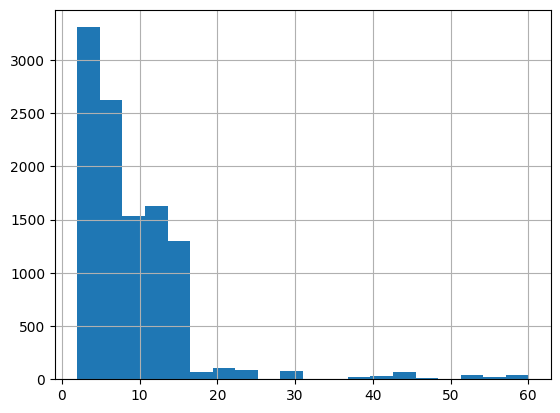

In [ ]:
#建物回数の分布を表示
plt.hist(df["建物階数"], bins=20)
plt.grid(True)

15階建以下がメインですが、一部50階超えのタワーマンションもあるようです。

#### <font color=#0e89b2>c. 所在階数</font>

In [ ]:
#階数のデータの種類を表示。
df['階数'].unique()

array(['4階', '5階', '8階', '2階', '3階', '9階', '12階', '1階', '6階', '10階',
       '11階', '7階', '1-3階', '13階', '14階', '19階', '25階', '40階', '18階',
       '39階', '28階', '17階', '29階', '22階', '31階', '34階', '50階', '53階', '-',
       '1-2階', '15階', '33階', '32階', '16階', 'B1階', 'B1-1階', '2-1階', '2-3階',
       '24階', '30階', '26階', '21階', '27階', '12-13階', '4-5階', '42階', '20階',
       '23階', '1-1階', '35階', '36階', '37階', '43階', '45階', '49階', '54階',
       '38階', '41階', '55階', '52階', '58階', '9-10階', '4-4階', '1-B1階'],
      dtype=object)

In [ ]:
#階数から階の文字、Bの文字、-を取り除く処理

#空の変換前と変換後のリストを作成
before_floor_list = []
after_floor_list = []

#階数のデータをbefore_floor_listにリスト型に変換して代入
before_floor_list = df['階数'].to_list()

#for文でbefore_floor_listの要素を1つずつ抽出
for floor in before_floor_list:

  #階数が'-'の場合
  if floor == '-':

    #1階としてafter_floor_listに追加
    after_floor_list.append(1)

  #階数が'-'を含む場合
  elif '-' in floor:

    #階数が'-'で分割して、後半をafter_floorに代入
    after_floor = floor.split("-")[1]

    #after_floorから'階'の文字を取り除く
    after_floor = after_floor.strip('階')
    after_floor = after_floor.strip('B')

    #after_floorは数字のみが残るので、int型に変換
    after_floor = int(after_floor)

    #after_floor_listに追加
    after_floor_list.append(after_floor)

  #階数が'B'を含む場合
  elif 'B' in floor:

     #floorから'B'の文字を取り除く
     after_floor = floor.strip('B')

     #after_floorから'階'の文字を取り除く
     after_floor = after_floor.strip('階')

     #after_floorは数字のみが残るので、int型に変換
     after_floor = int(after_floor)

     #after_floor_listに追加
     after_floor_list.append(after_floor)

  #階数が～階の場合
  else:

     #floorから''階'の文字を取り除く
     after_floor = floor.strip('階')
     #after_floorは数字のみが残るので、int型に変換
     after_floor = int(after_floor)

     #after_floor_listに追加
     after_floor_list.append(after_floor)

#変換後のafter_floor_listをdf['階数']に代入
df['階数'] = after_floor_list

In [ ]:
#変換後の階数のデータの種類を表示。
df['階数'].unique()

array([ 4,  5,  8,  2,  3,  9, 12,  1,  6, 10, 11,  7, 13, 14, 19, 25, 40,
       18, 39, 28, 17, 29, 22, 31, 34, 50, 53, 15, 33, 32, 16, 24, 30, 26,
       21, 27, 42, 20, 23, 35, 36, 37, 43, 45, 49, 54, 38, 41, 55, 52, 58])

#### <font color=#0e89b2>d. 家賃</font>

In [ ]:
#家賃のデータの種類を表示。
df['家賃'].unique()

array(['32万円', '22万円', '12万円', '13万円', '11万円', '9万円', '9.9万円', '10.05万円',
       '10.25万円', '10.6万円', '13.4万円', '18.3万円', '18.35万円', '18.4万円',
       '18.6万円', '18.7万円', '18.8万円', '18.9万円', '19.2万円', '9.5万円', '9.7万円',
       '10.5万円', '13.3万円', '13.6万円', '9.2万円', '11.8万円', '21.9万円',
       '22.4万円', '22.5万円', '22.8万円', '23万円', '23.3万円', '13.2万円', '13.5万円',
       '9.4万円', '15.9万円', '13.9万円', '14万円', '6.75万円', '16.2万円', '10.8万円',
       '10.9万円', '11.1万円', '11.3万円', '11.4万円', '19.4万円', '12.9万円',
       '16.89万円', '8万円', '8.2万円', '8.3万円', '8.4万円', '8.5万円', '8.6万円',
       '12.5万円', '12.7万円', '15万円', '8.55万円', '8.7万円', '8.75万円', '8.8万円',
       '8.85万円', '8.9万円', '8.95万円', '14.2万円', '14.4万円', '6.9万円', '7万円',
       '7.1万円', '7.3万円', '7.5万円', '9.8万円', '11.7万円', '10.4万円', '10.7万円',
       '12.3万円', '16.7万円', '16.9万円', '17万円', '17.5万円', '18.5万円', '14.3万円',
       '14.6万円', '15.3万円', '6.7万円', '9.35万円', '10.2万円', '21.3万円',
       '12.2万円', '24万円', '7.8万円', '11.5万円', '14.1万円', '14.7万円', '19.6万円

In [ ]:
#万円の文字を削除
df['家賃'] = df['家賃'].str.strip('万円')

#データ型をfloat(浮動小数点)に変換
df['家賃']  = df['家賃'].astype(float)

In [ ]:
#変換後の家賃のデータの種類を表示。
df['家賃'].unique()

array([ 32.  ,  22.  ,  12.  ,  13.  ,  11.  ,   9.  ,   9.9 ,  10.05,
        10.25,  10.6 ,  13.4 ,  18.3 ,  18.35,  18.4 ,  18.6 ,  18.7 ,
        18.8 ,  18.9 ,  19.2 ,   9.5 ,   9.7 ,  10.5 ,  13.3 ,  13.6 ,
         9.2 ,  11.8 ,  21.9 ,  22.4 ,  22.5 ,  22.8 ,  23.  ,  23.3 ,
        13.2 ,  13.5 ,   9.4 ,  15.9 ,  13.9 ,  14.  ,   6.75,  16.2 ,
        10.8 ,  10.9 ,  11.1 ,  11.3 ,  11.4 ,  19.4 ,  12.9 ,  16.89,
         8.  ,   8.2 ,   8.3 ,   8.4 ,   8.5 ,   8.6 ,  12.5 ,  12.7 ,
        15.  ,   8.55,   8.7 ,   8.75,   8.8 ,   8.85,   8.9 ,   8.95,
        14.2 ,  14.4 ,   6.9 ,   7.  ,   7.1 ,   7.3 ,   7.5 ,   9.8 ,
        11.7 ,  10.4 ,  10.7 ,  12.3 ,  16.7 ,  16.9 ,  17.  ,  17.5 ,
        18.5 ,  14.3 ,  14.6 ,  15.3 ,   6.7 ,   9.35,  10.2 ,  21.3 ,
        12.2 ,  24.  ,   7.8 ,  11.5 ,  14.1 ,  14.7 ,  19.6 ,  20.1 ,
        21.4 ,   9.1 ,  12.4 ,  12.8 ,  15.2 ,  15.5 ,  15.6 ,  17.1 ,
        17.6 ,  17.7 ,  20.3 ,  20.2 ,  20.6 ,  21.2 ,  21.8 ,  26.  ,
      

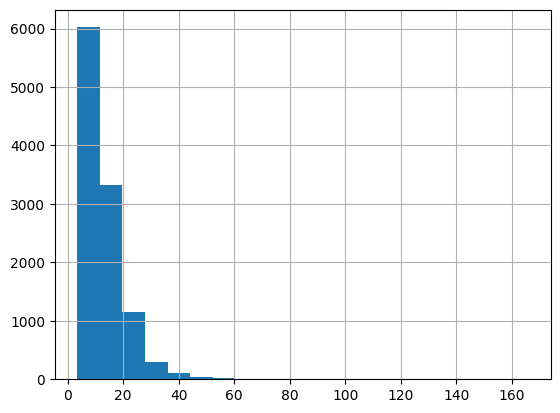

In [ ]:
#家賃の分布を表示
plt.hist(df["家賃"], bins=20)
plt.grid(True)

家賃10万円前後がボリュームゾーンのようです。

#### <font color=#0e89b2>e. 面積</font>

In [ ]:
#面積のデータの種類を表示。
df['面積'].unique()

array(['73.62m2', '80.73m2', '90.48m2', ..., '24.88m2', '19.75m2',
       '86.42m2'], dtype=object)

In [ ]:
#m2の文字を削除 最初の文字から最後から３番目の文字までスライス
#df['面積'] = df['面積'].str[:-3]
df["面積"] = df["面積"].str.split("m2", expand=True)[0].astype(float)
#データ型をfloat(浮動小数点)に変換
df['面積'] = df['面積'].astype(float)

In [ ]:
#変換後の面積のデータの種類を表示。
df['面積'].unique()

array([73.62, 80.73, 90.48, ..., 24.88, 19.75, 86.42])

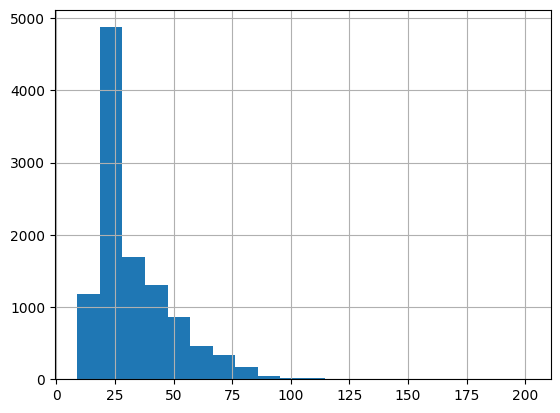

In [ ]:
#面積の分布を表示
plt.hist(df["面積"], bins=20)
plt.grid(True)

ほとんどが20平米以上の物件で、狭小物件のデータ数が少なくなってしまっているのが気になりますが、<br>
このまま進めていきましょう。

### <font color=#0e89b2>(3) データ前処理③：カテゴリデータからOneHotベクトルへ変換</font>

カテゴリデータをOneHotベクトルに変換していきます。


#### <font color=#0e89b2>a. 住所</font>

In [ ]:
#東京都の文字を削除
df['住所'] = df['住所'].str.strip('東京都')

#区名だけを週出　applyメソッドでlambda関数を適用しています。
df['住所'] = df["住所"].apply(lambda s: s.split("区")[0])

In [ ]:
#変換後の住所のデータの種類を表示
df['住所'].unique()

array(['渋谷', '荒川', '葛飾', '足立', '文京', '墨田', '台東', '江戸川', '中野', '中央', '千代田',
       '豊島', '練馬', '江東', '板橋', '目黒', '北', '杉並', '品川', '世田谷', '大田', '港',
       '新宿'], dtype=object)

In [ ]:
#23区揃っているか確認
len(df['住所'].unique())

23

おや？19区しかありません。<br>
どうやら世田谷区、港区、新宿区、大田区の物件が含まれていないようです。<br>
これらの区の物件の家賃予測はできなくなりますが、今回はこのまま進めていきましょう。

#### <font color=#0e89b2>b. 建物種別</font>

In [ ]:
#種別のデータの種類を表示。このままOnehotベクトル化します。
df['種別'].unique()

array(['賃貸マンション', '賃貸アパート', '賃貸一戸建て', '賃貸テラス・タウンハウス'], dtype=object)

#### <font color=#0e89b2>c. 間取り</font>

In [ ]:
#間取りのデータの種類を表示。このままOnehotベクトル化します。
df['間取り'].unique()

array(['2LDK', '3SLDK', '4LDK', '1LDK', '1K', '1DK', '1SLDK', '2SLDK',
       '3LDK', '1SK', 'ワンルーム', '2DK', '12SLDK', '3DK', '1SDK', '2K',
       '4DK', '2SDK', '3SK', '4SLDK', '1LK', '6LDK', '5SLDK'],
      dtype=object)

#### <font color=#0e89b2>d. OneHotベクトル化</font>

Onehotベクトル化を行うには、pandas(pd)のget_dummiesメソッドを使用します。<br>
カテゴリデータのみOnehotベクトル化されます。<br>

In [ ]:
df = pd.get_dummies(df)

In [ ]:
#Onehotベクトル化後は項目(カラム)数が増えます。
df.head()

,築年数,建物階数,階数,家賃,面積,種別_賃貸アパート,種別_賃貸テラス・タウンハウス,種別_賃貸マンション,種別_賃貸一戸建て,住所_世田谷,住所_中央,住所_中野,住所_北,住所_千代田,住所_台東,住所_品川,住所_墨田,住所_大田,住所_文京,住所_新宿,住所_杉並,住所_板橋,住所_江戸川,住所_江東,住所_渋谷,住所_港,住所_目黒,住所_練馬,住所_荒川,住所_葛飾,住所_豊島,住所_足立,間取り_12SLDK,間取り_1DK,間取り_1K,間取り_1LDK,間取り_1LK,間取り_1SDK,間取り_1SK,間取り_1SLDK,間取り_2DK,間取り_2K,間取り_2LDK,間取り_2SDK,間取り_2SLDK,間取り_3DK,間取り_3LDK,間取り_3SK,間取り_3SLDK,間取り_4DK,間取り_4LDK,間取り_4SLDK,間取り_5SLDK,間取り_6LDK,間取り_ワンルーム
0,26,15,4,32.0,73.62,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,20,20,5,22.0,80.73,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,20,20,8,22.0,90.48,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,15,13,2,12.0,41.09,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,15,13,5,13.0,43.18,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### <font color=#0e89b2>(4) データ前処理④：目的変数と説明変数を分離</font>

家賃を目的変数(Y)にして、その他を説明変数(X)にします。

In [ ]:
X = df.drop('家賃',axis=1)
Y = df['家賃']

### <font color=#0e89b2>(5) データ前処理⑤：数値データの標準化</font>

標準化(Standardization)とは、数値データを平均0、分散1に変換(スケーリング)することを言います。<br>
<br>
なぜこの標準化が必要か、今回のデータの文脈で改めて説明します。<br>
例えばある物件のデータを見てみると、このようになっています。

*   管理費 0.4
*   面積 78.96
<br>

この場合、機械学習モデルは数値の大きい面積を重要視してしまいます。<br>
それを避けるために、すべての数値データを平均0、分散1に変換する標準化が必要になります。。<br>
<br>
標準化を行う時は、sklearnのStandardScaler()を使用します。

In [ ]:
#比較のため標準化前の説明変数(X)をDataFrameとして保存しておきます。
X_before = pd.DataFrame(X)

#比較のため標準化前の説明変数(X)の項目名を保存しておきます。
X_before_col = X_before.columns

#sklearnのStandardScaler()を定義します。
scaler = StandardScaler()

#StandardScaler()で標準化を行います。
X_Standard = scaler.fit_transform(X)

比較のために標準化前の説明変数(X)を表示させてましょう。

In [ ]:
X_before.head()

,築年数,建物階数,階数,面積,種別_賃貸アパート,種別_賃貸テラス・タウンハウス,種別_賃貸マンション,種別_賃貸一戸建て,住所_世田谷,住所_中央,住所_中野,住所_北,住所_千代田,住所_台東,住所_品川,住所_墨田,住所_大田,住所_文京,住所_新宿,住所_杉並,住所_板橋,住所_江戸川,住所_江東,住所_渋谷,住所_港,住所_目黒,住所_練馬,住所_荒川,住所_葛飾,住所_豊島,住所_足立,間取り_12SLDK,間取り_1DK,間取り_1K,間取り_1LDK,間取り_1LK,間取り_1SDK,間取り_1SK,間取り_1SLDK,間取り_2DK,間取り_2K,間取り_2LDK,間取り_2SDK,間取り_2SLDK,間取り_3DK,間取り_3LDK,間取り_3SK,間取り_3SLDK,間取り_4DK,間取り_4LDK,間取り_4SLDK,間取り_5SLDK,間取り_6LDK,間取り_ワンルーム
0,26,15,4,73.62,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,20,20,5,80.73,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,20,20,8,90.48,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,15,13,2,41.09,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,15,13,5,43.18,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


標準化後の説明変数(X)を表示させてましょう。<br>
このように数値データが平均0、分散1に変換(スケーリング)されいます。

In [ ]:
#標準化後の説明変数(X)をDataFrameに変換、そのときの項目名は変換前ものをつける
X_after = pd.DataFrame(X_Standard,columns=X_before_col)

X_after.head()

,築年数,建物階数,階数,面積,種別_賃貸アパート,種別_賃貸テラス・タウンハウス,種別_賃貸マンション,種別_賃貸一戸建て,住所_世田谷,住所_中央,住所_中野,住所_北,住所_千代田,住所_台東,住所_品川,住所_墨田,住所_大田,住所_文京,住所_新宿,住所_杉並,住所_板橋,住所_江戸川,住所_江東,住所_渋谷,住所_港,住所_目黒,住所_練馬,住所_荒川,住所_葛飾,住所_豊島,住所_足立,間取り_12SLDK,間取り_1DK,間取り_1K,間取り_1LDK,間取り_1LK,間取り_1SDK,間取り_1SK,間取り_1SLDK,間取り_2DK,間取り_2K,間取り_2LDK,間取り_2SDK,間取り_2SLDK,間取り_3DK,間取り_3LDK,間取り_3SK,間取り_3SLDK,間取り_4DK,間取り_4LDK,間取り_4SLDK,間取り_5SLDK,間取り_6LDK,間取り_ワンルーム
0,1.153378,0.793694,-0.161273,2.344136,-0.384991,-0.028635,0.397213,-0.080082,-0.235238,-0.215151,-0.196903,-0.212591,-0.179259,-0.180069,-0.226488,-0.22201,-0.288305,-0.138243,-0.255266,-0.235453,-0.353463,-0.121575,-0.214688,4.960450,-0.205235,-0.162024,-0.206196,-0.179259,-0.138243,-0.198642,-0.233942,-0.009542,-0.321316,-0.738393,-0.467755,-0.009542,-0.023377,-0.035722,-0.080656,-0.123109,-0.118058,2.805919,-0.013494,-0.109008,-0.03937,-0.195903,-0.009542,-0.041625,-0.021339,-0.035722,-0.013494,-0.023377,-0.013494,-0.451482
1,0.680831,1.431466,0.042615,2.758714,-0.384991,-0.028635,0.397213,-0.080082,-0.235238,-0.215151,-0.196903,-0.212591,-0.179259,-0.180069,-0.226488,-0.22201,-0.288305,-0.138243,-0.255266,-0.235453,-0.353463,-0.121575,-0.214688,-0.201595,-0.205235,-0.162024,-0.206196,5.578520,-0.138243,-0.198642,-0.233942,-0.009542,-0.321316,-0.738393,-0.467755,-0.009542,-0.023377,-0.035722,-0.080656,-0.123109,-0.118058,-0.356389,-0.013494,-0.109008,-0.03937,-0.195903,-0.009542,24.024111,-0.021339,-0.035722,-0.013494,-0.023377,-0.013494,-0.451482
2,0.680831,1.431466,0.654280,3.327229,-0.384991,-0.028635,0.397213,-0.080082,-0.235238,-0.215151,-0.196903,-0.212591,-0.179259,-0.180069,-0.226488,-0.22201,-0.288305,-0.138243,-0.255266,-0.235453,-0.353463,-0.121575,-0.214688,-0.201595,-0.205235,-0.162024,-0.206196,5.578520,-0.138243,-0.198642,-0.233942,-0.009542,-0.321316,-0.738393,-0.467755,-0.009542,-0.023377,-0.035722,-0.080656,-0.123109,-0.118058,-0.356389,-0.013494,-0.109008,-0.03937,-0.195903,-0.009542,-0.041625,-0.021339,27.993622,-0.013494,-0.023377,-0.013494,-0.451482
3,0.287042,0.538585,-0.569050,0.447340,-0.384991,-0.028635,0.397213,-0.080082,-0.235238,-0.215151,-0.196903,-0.212591,-0.179259,-0.180069,-0.226488,-0.22201,-0.288305,-0.138243,-0.255266,-0.235453,-0.353463,-0.121575,-0.214688,-0.201595,-0.205235,-0.162024,-0.206196,5.578520,-0.138243,-0.198642,-0.233942,-0.009542,-0.321316,-0.738393,2.137870,-0.009542,-0.023377,-0.035722,-0.080656,-0.123109,-0.118058,-0.356389,-0.013494,-0.109008,-0.03937,-0.195903,-0.009542,-0.041625,-0.021339,-0.035722,-0.013494,-0.023377,-0.013494,-0.451482
4,0.287042,0.538585,0.042615,0.569206,-0.384991,-0.028635,0.397213,-0.080082,-0.235238,-0.215151,-0.196903,-0.212591,-0.179259,-0.180069,-0.226488,-0.22201,-0.288305,-0.138243,-0.255266,-0.235453,-0.353463,-0.121575,-0.214688,-0.201595,-0.205235,-0.162024,-0.206196,5.578520,-0.138243,-0.198642,-0.233942,-0.009542,-0.321316,-0.738393,2.137870,-0.009542,-0.023377,-0.035722,-0.080656,-0.123109,-0.118058,-0.356389,-0.013494,-0.109008,-0.03937,-0.195903,-0.009542,-0.041625,-0.021339,-0.035722,-0.013494,-0.023377,-0.013494,-0.451482


### <font color=#0e89b2>(6) データ前処理⑥：trainデータとtestデータに分割</font>

sklearnのtrain_test_splitを用いて、説明変数(X)と目的変数(Y)を<br>
訓練(train)データと評価(test)データにランダムに分割します。<br>
比率はtest_size=0.3に設定しているので、以下の比率で分割されますs。<br>


> 訓練(train)データ:評価(test)データ = 70 : 30<br>


また引数random_stateを固定しておくと、毎回同じになるように分割できます。


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X_Standard, Y, test_size=0.3, random_state=0)

## <font color=#0e89b2>5.3 モデル学習/評価</font>

モデルの学習と評価を行っていきます。<br>
引数にmodelを入れると学習と評価を行ってくれる関数predict_functionを用意しておきます。

In [ ]:
#関数定義　引数:model
def predict_function(model):
    #モデル学習
    model.fit(x_train,y_train)

    #テストデータでのモデル評価
    pred = model.predict(x_test)

    #評価指標を求めて記録する
    MAE.append(mean_absolute_error(pred,y_test))
    MSE.append(mean_squared_error(pred,y_test))
    RMSE.append(np.sqrt(mean_squared_error(pred,y_test)))

この関数を使って、モデル学習と評価を行っていきましょう。<br>
モデルは<br>

*   LinearRegression()<br>
*   DecisionTreeRegressor()<br>
*   RandomForestRegressor()<br>
*   GradientBoostingRegressor()<br>
*   lgb.LGBMRegressor()<br>
*   xgb.XGBRegressor()<br>

を使用します。<br>
<br>
評価指標は以下の3つを使用します。


*   MAE...平均絶対誤差 (MAE, Mean Absolute Error)
*   MSE...平均二乗誤差 (MSE, Mean Squared Error)
*   RMSE...二乗平均平方根誤差 (RMSE: Root Mean Squared Error)




In [ ]:
#評価指標を記録するためのリストを定義
MAE=[]
MSE=[]
RMSE=[]

#使用するモデルをリスト型で定義
models=[LinearRegression(),DecisionTreeRegressor(),RandomForestRegressor(),GradientBoostingRegressor(),lgb.LGBMRegressor(),xgb.XGBRegressor()]

#使用するモデル名をリスト型で定義
model_names=['LinearRegression','DecisionTreeRegressor','RandomForestRegressor','GradientBoostingRegressor','LightGBMRegressor','XGBoostRegressor']

#for文で先ほど定義したモデルを１つずつ呼び出し
for model in range(len(models)):
    #先ほど定義したpredict_functionでモデル学習/評価を実行
    predict_function(models[model])

#評価結果を辞書に格納
result ={'Modelling Algo':model_names,'MAE':MAE,'MSE':MSE,'RMSE':RMSE}

#評価結果を辞書からDataFrame型に変換
metrics_df=pd.DataFrame(result)

#評価結果の表示
metrics_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 501
[LightGBM] [Info] Number of data points in the train set: 7689, number of used features: 40
[LightGBM] [Info] Start training from score 13.228823


,Modelling Algo,MAE,MSE,RMSE
0,LinearRegression,1.899681e+12,5.956992e+27,7.718155e+13
1,DecisionTreeRegressor,8.018409e-01,6.728820e+00,2.593997e+00
2,RandomForestRegressor,7.493057e-01,4.387734e+00,2.094692e+00
3,GradientBoostingRegressor,1.357139e+00,5.344829e+00,2.311889e+00
4,LightGBMRegressor,1.066717e+00,6.995857e+00,2.644968e+00
5,XGBoostRegressor,8.652880e-01,6.041458e+00,2.457938e+00


評価結果<br>
今回の評価結果は、MAEについてはRandomForestRegressor、MSE/RMSEについてはGradientBoostingRegressorがベストでした。

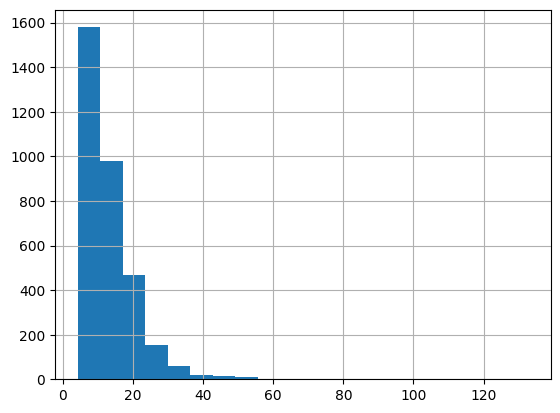

In [ ]:
import matplotlib.pyplot as plt
model = RandomForestRegressor()

#モデル学習
model.fit(x_train,y_train)

#テストデータでのモデル評価
pred = model.predict(x_test)

#予測結果を描画
plt.hist(pred, bins=20)
plt.grid(True)

In [ ]:
x_test

array([[-0.89432694, -0.35429588, -0.16127319, ..., -0.02337729,
        -0.01349443, -0.45148158],
       [ 0.60207312, -0.73695912, -0.77293829, ..., -0.02337729,
        -0.01349443, -0.45148158],
       [-0.65805325, -0.4818503 , -0.16127319, ..., -0.02337729,
        -0.01349443, -0.45148158],
       ...,
       [ 0.68083102,  0.53858501,  1.6737221 , ..., -0.02337729,
        -0.01349443, -0.45148158],
       [-0.18550586,  1.3039115 ,  1.46983373, ..., -0.02337729,
        -0.01349443, -0.45148158],
       [-0.89432694, -0.4818503 , -0.56904992, ..., -0.02337729,
        -0.01349443,  2.21492979]])

## <font color=#0e89b2>5.4 自宅の家賃を予測</font>

RandomForestRegressorのモデルで、自宅の家賃を予測してみましょう。

### <font color=#0e89b2>(1) 自宅のデータを準備</font>

まずは自分の家のデータを準備します。<br>
（以下のデータはダミーデータです）

In [ ]:
my_home_data = {
    "種別":["賃貸マンション"],
    "住所":["東京都品川区"],
    "築年数":["築3年"],
    "建物階数":["25階建"],
    "階数":["25階"],
    "間取り":["2LDK"],
    "面積":["62m2"]}

### <font color=#0e89b2>(2) データの前処理</font>

先ほど行った前処理工程を関数化しておきます。

In [ ]:
def age_processor(df):
  #築年数の内、新築は0に置換　str.replaceメソッドを使用
  df['築年数'] = df['築年数'].str.replace('新築','0')

  #築年数の内、築と年の文字を削除　str.stripメソッドを使用
  df['築年数'] = df['築年数'].str.strip('築年')

  #データ型をint(整数)に変換　astypeメソッドを使用
  df['築年数'] = df['築年数'].astype(int)
  return df

In [ ]:
def building_height_processor(df):
  #地下は簡略化のため、削除する。str.replaceメソッドで無しに置換
  df['建物階数'] = df['建物階数'].str.replace('地下1地上','')
  df['建物階数'] = df['建物階数'].str.replace('地下2地上','')
  df['建物階数'] = df['建物階数'].str.replace('地下3地上','')
  df['建物階数'] = df['建物階数'].str.replace('地下4地上','')
  df['建物階数'] = df['建物階数'].str.replace('地下5地上','')

  #階建の文字を削除
  df['建物階数'] = df['建物階数'].str.strip('階建')

  #データ型をint(整数)に変換
  df['建物階数'] = df['建物階数'].astype(int)
  return df

In [ ]:
def height_processor(df):
  #階数から階の文字、Bの文字、-を取り除く処理

  #空の変換前と変換後のリストを作成
  before_floor_list = []
  after_floor_list = []

  #階数のデータをbefore_floor_listにリスト型に変換して代入
  before_floor_list = df['階数'].to_list()

  #for文でbefore_floor_listの要素を1つずつ抽出
  for floor in before_floor_list:

    #階数が'-'の場合
    if floor == '-':

      #1階としてafter_floor_listに追加
      after_floor_list.append(1)

    #階数が'-'を含む場合
    elif '-' in floor:

      #階数が'-'で分割して、後半をafter_floorに代入
      after_floor = floor.split("-")[1]

      #after_floorから'階'の文字を取り除く
      after_floor = after_floor.strip('階')

      #after_floorは数字のみが残るので、int型に変換
      after_floor = int(after_floor)

      #after_floor_listに追加
      after_floor_list.append(after_floor)

    #階数が'B'を含む場合
    elif 'B' in floor:

      #floorから'B'の文字を取り除く
      after_floor = floor.strip('B')

      #after_floorから'階'の文字を取り除く
      after_floor = after_floor.strip('階')

      #after_floorは数字のみが残るので、int型に変換
      after_floor = int(after_floor)

      #after_floor_listに追加
      after_floor_list.append(after_floor)

    #階数が～階の場合
    else:

      #floorから''階'の文字を取り除く
      after_floor = floor.strip('階')
      #after_floorは数字のみが残るので、int型に変換
      after_floor = int(after_floor)

      #after_floor_listに追加
      after_floor_list.append(after_floor)

  #変換後のafter_floor_listをdf['階数']に代入
  df['階数'] = after_floor_list
  return df

In [ ]:
def area_processor(df):
  #m2の文字を削除 最初の文字から最後から３番目の文字までスライス
  df['面積'] = df['面積'].str[:-2]

  #データ型をfloat(浮動小数点)に変換
  df['面積'] = df['面積'].astype(float)
  return df

In [ ]:
def address_processor(df):
  #東京都の文字を削除
  df['住所'] = df['住所'].str.strip('東京都')

  #区名だけを週出　applyメソッドでlambda関数を適用しています。
  df['住所'] = df["住所"].apply(lambda s: s.split("区")[0])
  return df

In [ ]:
def standardize(df):
  # #比較のため標準化前の説明変数(X)の項目名を保存しておきます。
  X_before_col = df.columns

  #sklearnのStandardScaler()を定義します。
  scaler = StandardScaler()

  #StandardScaler()で標準化を行います。
  standardized = scaler.fit_transform(df)

  #説明変数(X)に標準化後の説明変数(X_Standard)を代入します。
  standardized_df = pd.DataFrame(standardized, columns=X_before_col)
  return standardized_df

前処理を行っていきます。

In [ ]:
#自宅データをデータフレーム化
my_home = pd.DataFrame(my_home_data)

#カテゴリデータから数値データへ変換
my_home = age_processor(my_home)
my_home = building_height_processor(my_home)
my_home = height_processor(my_home)
my_home = area_processor(my_home)

#カテゴリデータからOneHotベクトルへ変換
my_home = address_processor(my_home)
my_home = pd.get_dummies(my_home)

#標準化
my_home = pd.concat([my_home, X_before])
my_home = my_home.fillna(0)
before_col = my_home.columns
my_home = scaler.fit_transform(my_home)
my_home = pd.DataFrame(my_home, columns=before_col)
my_home = my_home.head(1)

#モデルのインプット形式に合うよう、データを整形（この作業をしないと、ダミー変数カラムが抜け落ちて、エラーが出てしまいます）
data_format = X_after.drop(range(len(X_after)))
my_home = pd.concat([data_format, my_home])

In [ ]:
my_home

,築年数,建物階数,階数,面積,種別_賃貸アパート,種別_賃貸テラス・タウンハウス,種別_賃貸マンション,種別_賃貸一戸建て,住所_世田谷,住所_中央,住所_中野,住所_北,住所_千代田,住所_台東,住所_品川,住所_墨田,住所_大田,住所_文京,住所_新宿,住所_杉並,住所_板橋,住所_江戸川,住所_江東,住所_渋谷,住所_港,住所_目黒,住所_練馬,住所_荒川,住所_葛飾,住所_豊島,住所_足立,間取り_12SLDK,間取り_1DK,間取り_1K,間取り_1LDK,間取り_1LK,間取り_1SDK,間取り_1SK,間取り_1SLDK,間取り_2DK,間取り_2K,間取り_2LDK,間取り_2SDK,間取り_2SLDK,間取り_3DK,間取り_3LDK,間取り_3SK,間取り_3SLDK,間取り_4DK,間取り_4LDK,間取り_4SLDK,間取り_5SLDK,間取り_6LDK,間取り_ワンルーム
0,-0.65801,2.068741,4.117015,1.666298,-0.384971,-0.028634,0.397192,-0.080079,-0.235226,-0.215141,-0.196893,-0.212581,-0.179251,-0.18006,4.411134,-0.221999,-0.288291,-0.138237,-0.255253,-0.235442,-0.353445,-0.12157,-0.214678,-0.201585,-0.205225,-0.162017,-0.206186,-0.179251,-0.138237,-0.198633,-0.233931,-0.009541,-0.3213,-0.738341,-0.467729,-0.009541,-0.023376,-0.035721,-0.080652,-0.123103,-0.118052,2.804787,-0.013494,-0.109003,-0.039368,-0.195894,-0.009541,-0.041623,-0.021339,-0.035721,-0.013494,-0.023376,-0.013494,-0.451457


### <font color=#0e89b2>(3) モデルを構築</font>

RandomForestRegressorのモデルを構築します。<br>
学習データは、先ほどのものを使用します。

In [ ]:
#学習データとテストデータに分割
x_train, x_test, y_train, y_test = train_test_split(X_Standard, Y, test_size=0.3, random_state=0)

model = RandomForestRegressor()

#モデル学習
model.fit(x_train,y_train)

RandomForestRegressor()

### <font color=#0e89b2>(4) 予測</font>

In [ ]:
model.predict(my_home)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


array([30.5505])

それらしき家賃が予測できたでしょうか？<br>
（色々試してみて、Suumoで実際の物件の家賃を調べてみると面白いかも？）
<br>
先ほどのデータの分布で見た通り、<br>
現在の学習データには低家賃帯(6万円以下程度）の物件数が少ないので、低家賃帯の予測には弱くなっています。<br>
また、世田谷区、港区、新宿区、大田区の物件情報が含まれていないので、これらの区の物件の家賃は予測することができません。<br>
<br>
モデルを改良するためには、このあたりのデータを追加する必要があります。